In [4]:
import pandas as pd
import numpy as np

In [5]:
from matplotlib import pyplot as plt

In [6]:
from matplotlib import font_manager

font_dirs = ['/home/miner/fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["mathtext.fontset"] = 'cm'

In [3]:
# old_result_2SIC_p30 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/2SIC_p30_likelihood.csv')
# old_result_2SIC_p90 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/2SIC_p90_likelihood.csv')
# old_result_1IRA_p22 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/1IRA_p22_likelihood.csv')
# old_result_1IRA_p36 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/1IRA_p36_likelihood.csv')


single_traj_likelihoods = pd.read_csv('../../likelihood_results/likelihoodv3/dfmdock_tr_3integrand_traj_flow/likelihood.csv')
expanded_id = single_traj_likelihoods['id'].str.rsplit("_",n=1,expand=True)

times = expanded_id[1].astype(float)
ids = expanded_id[0]
single_traj_likelihoods['id'] = ids
single_traj_likelihoods['Timestep'] = times
single_traj_likelihoods['nll'] = -(single_traj_likelihoods['prior:smax_gaussian'] + single_traj_likelihoods['integrand:TotalIntegrand'])/3
# print(expanded_id.columns)

result_2SIC_p30 = single_traj_likelihoods[single_traj_likelihoods['id']=='2SIC_p30'].reset_index()
result_2SIC_p90 = single_traj_likelihoods[single_traj_likelihoods['id']=='2SIC_p90'].reset_index()
result_1IRA_p22 = single_traj_likelihoods[single_traj_likelihoods['id']=='1IRA_p22'].reset_index()
result_1IRA_p36 = single_traj_likelihoods[single_traj_likelihoods['id']=='1IRA_p36'].reset_index()


# result_2SIC_p30 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/2SIC_p30_likelihood.csv')
# result_2SIC_p90 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/2SIC_p90_likelihood.csv')
# result_1IRA_p22 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/1IRA_p22_likelihood.csv')
# result_1IRA_p36 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/1IRA_p36_likelihood.csv')

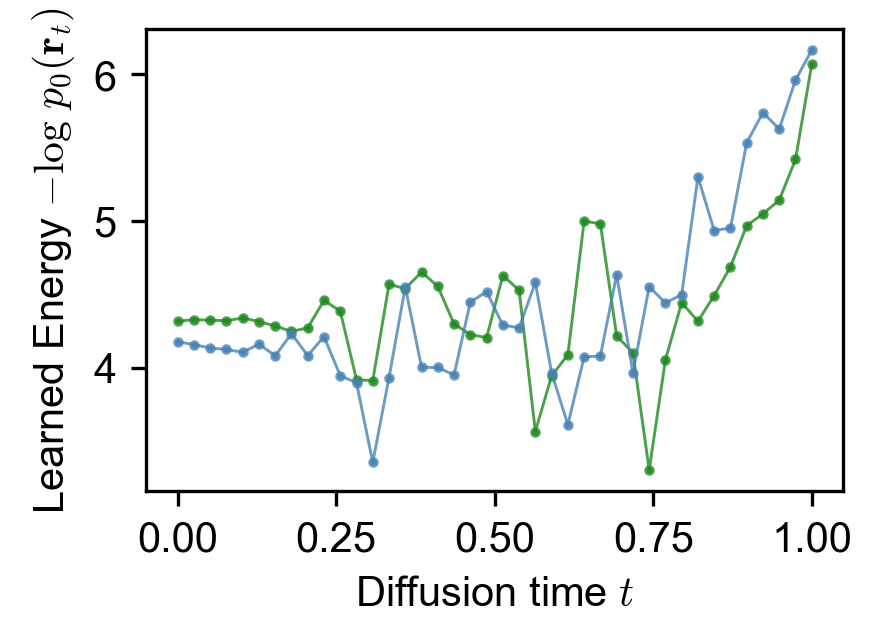

In [21]:
# plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, result_2SIC_p30.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, result_2SIC_p90.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p30['Timestep'], result_2SIC_p30.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90['Timestep'], result_2SIC_p90.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('2SIC_single_traj_likelihood_copy.png', dpi=300, bbox_inches='tight')

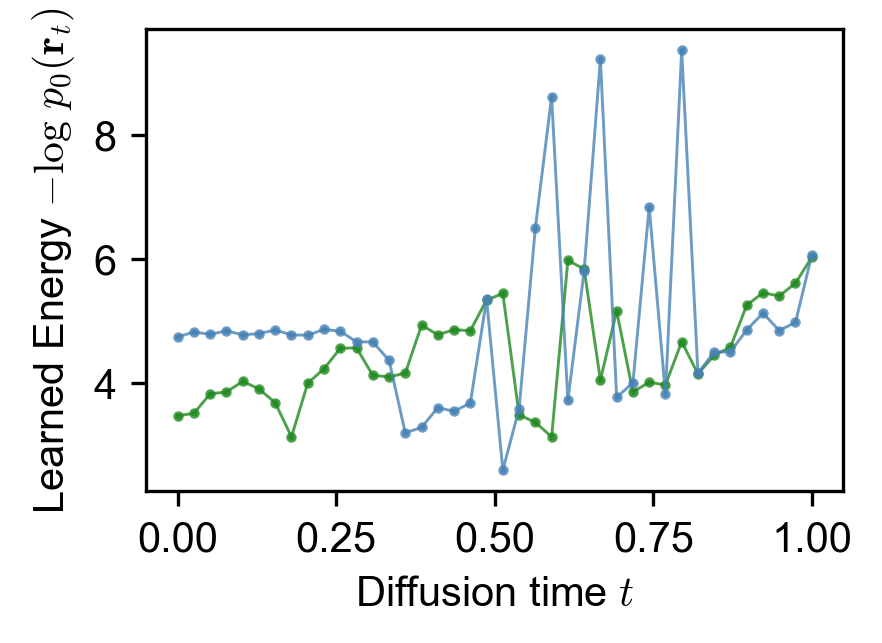

In [24]:
# plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, result_1IRA_p22.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, result_1IRA_p36.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p22['Timestep'], result_1IRA_p22.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36['Timestep'], result_1IRA_p36.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)


plt.xlabel('Diffusion time $t$')
plt.ylabel(r'Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('1IRA_single_traj_likelihood.png', dpi=300, bbox_inches='tight')

In [6]:
# with open('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_forces/traj_forces.pkl', 'rb') as f:
# import pickle
# with open('../../traj_forces.pkl', 'rb') as f:
#     traj_forces = pickle.load(f)
# old_traj_force_dict = {item['id'].split('/')[-1].split('.')[0]: item for item in traj_forces}

In [2]:
from pathlib import Path
import pandas as pd

def get_forces(forces_folder):
    index = pd.read_csv(forces_folder/'force_index.csv')
    
    cols = ["Offset_Tr_X", "Offset_Tr_Y", "Offset_Tr_Z"]
    score_cols = [f"score"]
    pos_cols = [f"pos"]
    
    traj_force_dict = {}
    for row in index.itertuples():
        id = row.id
        file = row.Forces_CSV
        forcedict = traj_force_dict[id] = {}
        forces = pd.read_csv(Path('..')/file)
        forcedict['id'] = id
        forcedict['time'] = forces['Timestep'].values
        forcedict['score'] = forces[score_cols].values
        forcedict['divergence] = forces['Divergence']
        forcedict['diff_coeff'] = forces['Diffusion_Coeff']
        forcedict['pos'] = forces[pos_cols].values

    return traj_force_dict

traj_forces = get_forces(Path('../../likelihood_results/likelihoodv3/3integrand_traj_forces_25'))
gt_traj_forces = get_forces(Path('../../likelihood_results/likelihoodv3/ground_truth/3integrand_traj_forces_25'))

    



In [11]:
(traj_forces[1]['score'] - gt_traj_forces[1]['score'])/abs(traj_forces[1]['score'])

array([[ 7.09744808e-01],
       [ 5.63748358e-01],
       [ 2.31083881e-01],
       [-7.61997080e-01],
       [-9.35347723e+00],
       [-5.50470792e+00],
       [-3.51826592e+00],
       [-3.34596921e+00],
       [-3.31161224e+00],
       [-3.65895884e+00],
       [-6.09251005e+00],
       [-9.30678566e+00],
       [-8.58258681e-01],
       [ 7.72912235e-03],
       [ 3.37932068e-01],
       [ 4.86918678e-01],
       [ 5.63888032e-01],
       [ 6.13899644e-01],
       [ 6.59629047e-01],
       [ 6.97545103e-01],
       [ 7.23123280e-01],
       [ 7.45172383e-01],
       [ 7.57865960e-01],
       [ 7.63994730e-01],
       [ 7.61056022e-01],
       [ 7.53456522e-01],
       [ 7.49088706e-01],
       [ 7.36166518e-01],
       [ 7.09216664e-01],
       [ 6.73819458e-01],
       [ 6.18055765e-01],
       [ 5.12380929e-01],
       [ 3.76119093e-01],
       [ 1.30613121e-01],
       [-3.02580444e-01],
       [-9.58419112e-01],
       [-1.81076574e+00],
       [-2.86869681e+00],
       [-5.2

In [43]:
np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1)[:-1]

array([13.80711213, 13.04798083, 11.27669965,  9.59182863,  8.14152795,
        6.96881634,  6.01043299,  5.19637847,  4.50044252,  3.90678933,
        3.40098184,  2.96837265,  2.60445872,  2.29520168,  2.02752784,
        1.78824054,  1.56916296,  1.36810862,  1.18032269,  1.01846322,
        0.87833929,  0.75336336,  0.64780219,  0.55995805,  0.48664424,
        0.41963668,  0.36184195,  0.3081061 ,  0.26333761,  0.22582551,
        0.19430573,  0.17017197,  0.14744786,  0.1267644 ,  0.10757578,
        0.09130502,  0.07676999,  0.06475867,  0.05595645])

In [11]:
np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1)

array([ 0.05003762,  0.05575769,  0.06411993,  0.07565591,  0.08984558,
        0.10526139,  0.1239167 ,  0.14440514,  0.16559692,  0.18830809,
        0.21717875,  0.2518789 ,  0.2934878 ,  0.3442848 ,  0.39845896,
        0.46111238,  0.52815586,  0.6072978 ,  0.7033837 ,  0.8175983 ,
        0.9459339 ,  1.0946532 ,  1.2661579 ,  1.4495616 ,  1.655812  ,
        1.8722193 ,  2.1149967 ,  2.3923151 ,  2.7056036 ,  3.0805798 ,
        3.519641  ,  4.0053487 ,  4.6259146 ,  5.3232865 ,  6.1478243 ,
        7.095358  ,  8.267866  ,  9.69955   , 11.3625765 , 13.066525  ],
      dtype=float32)

In [12]:
np.linalg.norm(traj_force_dict['2SIC_p90']['score'], axis=1)

array([ 0.0507055 ,  0.05643932,  0.06505388,  0.07662208,  0.08993647,
        0.10564165,  0.12398338,  0.14459364,  0.16430965,  0.18930897,
        0.21659239,  0.25189748,  0.29262388,  0.34390256,  0.39872208,
        0.4601644 ,  0.52820265,  0.6124155 ,  0.70460665,  0.8138327 ,
        0.94322455,  1.0955566 ,  1.2635767 ,  1.4525598 ,  1.6547132 ,
        1.8725202 ,  2.1178653 ,  2.392722  ,  2.70935   ,  3.0782611 ,
        3.4992027 ,  4.024721  ,  4.626727  ,  5.3240585 ,  6.1470056 ,
        7.094559  ,  8.265809  ,  9.699229  , 11.362286  , 13.077819  ],
      dtype=float32)

Text(0.5, 1.0, 'Force')

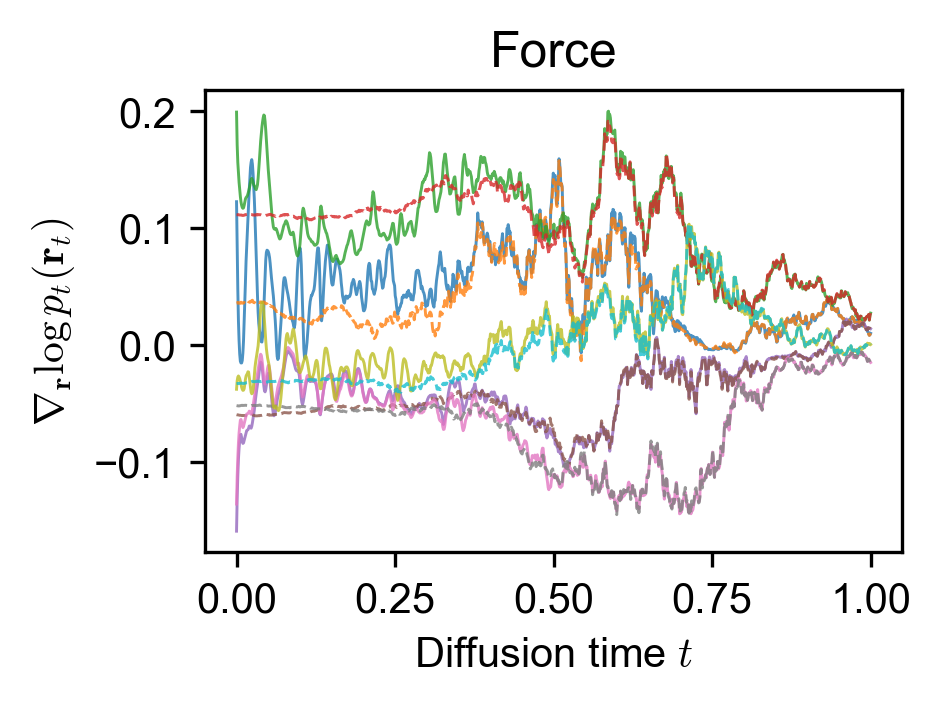

In [29]:
# plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

ids = [1,2,3,4,5]
# cs = ((0.13,0.54,0.13,1.0),(0.28,0.51,0.71,1.0))
for (id,) in zip(ids):
    plt.plot(traj_forces[id]['time'], traj_forces[id]['score'],  linestyle='-', markersize=0.6, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], gt_traj_forces[id]['score'], linestyle='--', markersize=0.6, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p30']['time'], np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], np.linalg.norm(traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title("Force")

Text(0.5, 1.0, 'Scaled Force')

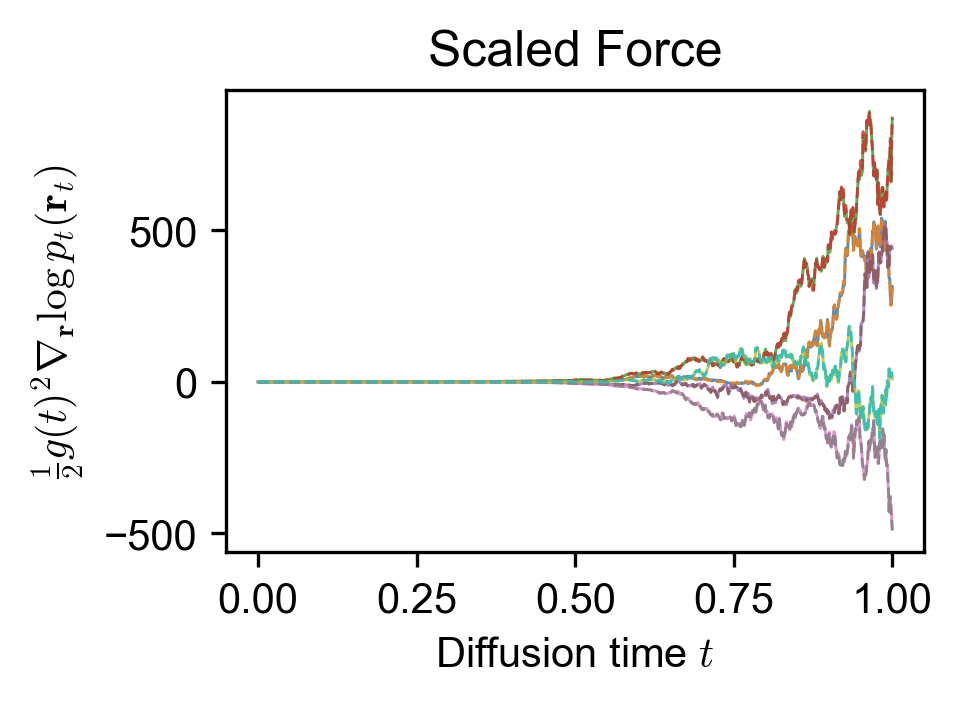

In [30]:
# plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

ids = [1,2,3,4,5]
# cs = ((0.13,0.54,0.13,1.0),(0.28,0.51,0.71,1.0))
for (id,) in zip(ids):
    plt.plot(traj_forces[id]['time'], 1/2*traj_forces[id]['score'][:,0]*traj_forces[id]['diff_coeff']**2,  linestyle='-', markersize=0.6, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], 1/2*gt_traj_forces[id]['score'][:,0]*gt_traj_forces[id]['diff_coeff']**2, linestyle='--', markersize=0.6, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p30']['time'], np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], np.linalg.norm(traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\frac{1}{2}g(t)^2\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title("Scaled Force")

Text(0.5, 1.0, 'Divergence')

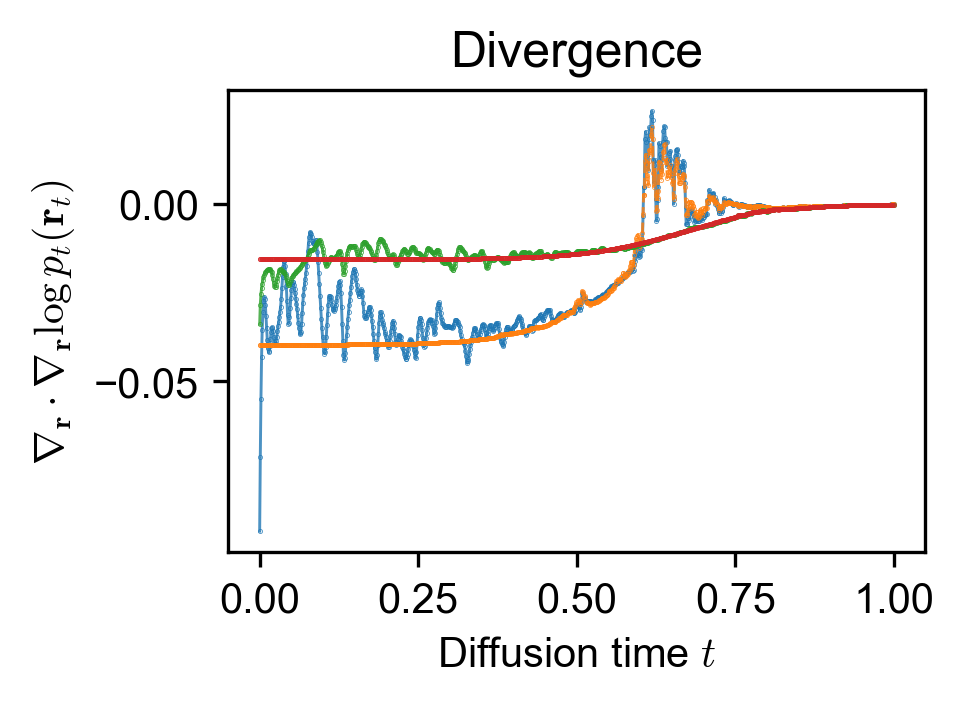

In [31]:
# plt.plot(traj_force_dict['2SIC_p30']['time'], traj_force_dict['2SIC_p30']['divergence], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], traj_force_dict['2SIC_p90']['divergence], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

for id in (1,2):
    plt.plot(traj_forces[id]['time'], traj_forces[id]['divergence], marker='o', linestyle='-', markersize=0.2, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], gt_traj_forces[id]['divergence], marker='o', linestyle='--', markersize=0.2, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\nabla_{\mathbf{r}} \cdot \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title('Divergence')

Text(0.5, 1.0, 'Scaled Divergence')

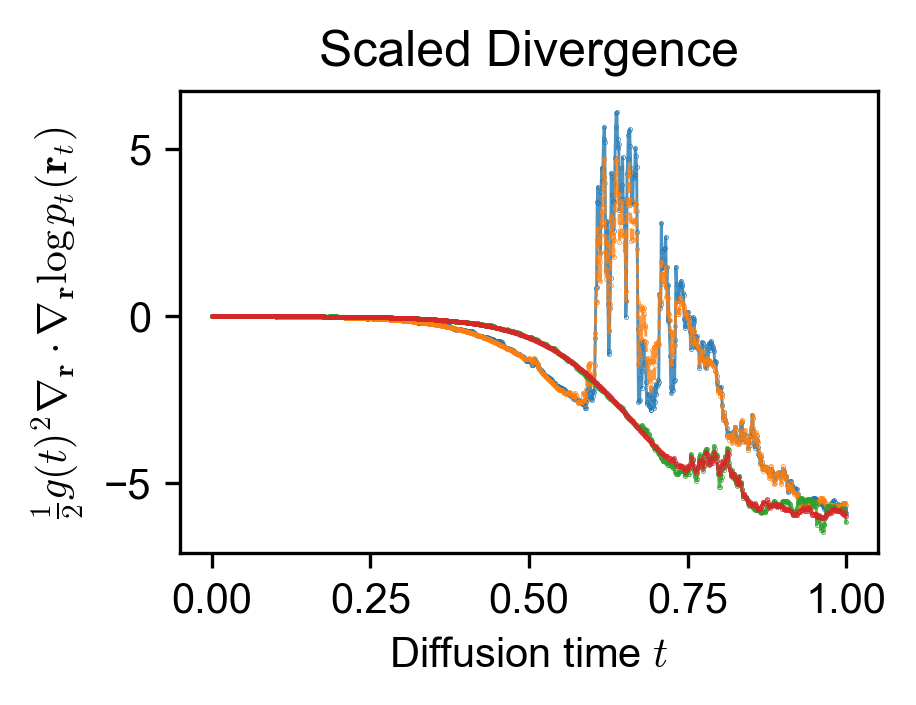

In [32]:
# plt.plot(traj_force_dict['2SIC_p30']['time'], 1/2*traj_force_dict['2SIC_p30']['diff_coeff']**2*traj_force_dict['2SIC_p30']['divergence'], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], 1/2*traj_force_dict['2SIC_p90']['diff_coeff']**2*traj_force_dict['2SIC_p90']['divergence'], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)


for id in (1,2):
    plt.plot(traj_forces[id]['time'], 1/2*traj_forces[id]['diff_coeff']**2*traj_forces[id]['divergence'], marker='o', linestyle='-', markersize=0.2, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], 1/2*gt_traj_forces[id]['diff_coeff']**2*gt_traj_forces[id]['divergence'], marker='o', linestyle='--', markersize=0.2, alpha=0.8, linewidth=0.7)


plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\frac{1}{2} g(t)^2 \nabla_{\mathbf{r}} \cdot \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title('Scaled Divergence')